# Final Project DS4420 - Eric Gerber 
Alina Gonzalez, Veronica Song, Sophia Yang 

Clean up and compile datasets from PetFinder dataset to match breed_id to breed, etc

Build out a CNN to identify key traits from animal given picture of pet
Build out MLP to predict adoption speed/ likelihood based off traits

In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

# imports for cnn
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.optimizers import SGD
from keras.losses import binary_crossentropy
from google.colab import drive

ModuleNotFoundError: No module named 'tensorflow'

In [7]:
# data cleanup

# data is organized kinda weirdly, train.csv has all the columns in one but gotta link breed_id to actual breed name
petfinder = pd.read_csv("petfinder-adoption-prediction_data/train/train.csv")
petfinder.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


# Building the MLP

In [10]:
# separating out y and x values

# trying to predict adoption speed
y = petfinder["AdoptionSpeed"]
y = y.to_numpy()

# extract visual variables used to build MLP
char = ["Breed1", "Breed2", "Color1", "Color2", "Color3", "MaturitySize", "FurLength"]
pet_char = petfinder[char]
X = pet_char

# Scaling with min-max scaler and adding bias column
scaler = MinMaxScaler()
X = scaler.fit_transform(X).round(2)

bias_col = np.ones((X.shape[0], 1))
X = np.hstack((bias_col, X))

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train

array([[1.  , 0.05, 1.  , ..., 0.  , 0.  , 0.5 ],
       [1.  , 0.01, 1.  , ..., 0.  , 0.33, 0.5 ],
       [1.  , 0.02, 0.86, ..., 0.  , 0.  , 1.  ],
       ...,
       [1.  , 0.33, 1.  , ..., 0.  , 0.33, 0.5 ],
       [1.  , 0.01, 0.87, ..., 0.86, 0.33, 0.  ],
       [1.  , 0.04, 1.  , ..., 0.  , 0.33, 0.  ]], shape=(10495, 9))

In [11]:
eta = .10 # this is my n value
epochs = 500
q = 4 # number of hidden nodes
n, d = X.shape

# Random initialization of initial weights
W1 = np.random.randn(d,q)
W2 = np.random.randn(q,1)

# defining the function
def f(x):
    h = np.maximum(0, W1.T.dot(x))
    return (1 / (1 + np.exp(-W2.T.dot(h))))

# defining relu function
def relu(x):
    return np.maximum(0, x)

In [17]:
errors = []

n = X_train.shape[0]   # number of training samples

for epoch in range(epochs):
    dW2 = 0
    dW1 = 0

    for i, j in enumerate(y_train):
        x = np.reshape(X_train[i], (d, 1))
        h = relu(W1.T.dot(x))
        dW2 += (1/n) * (f(x) - y_train[i]) * h

    for i, j in enumerate(y_train):
        x = np.reshape(X_train[i], (d, 1))
        h = relu(W1.T.dot(x))
        mat1 = np.heaviside(h, 0)
        dW1 += (1/n) * (f(x) - y_train[i]) * np.kron(x, (W2 * mat1).T)

    # Update weights
    W2 = W2 - eta * dW2
    W1 = W1 - eta * dW1

    # compute loss on training set
    per_sample_loss = -(y_train * np.log(f(X_train.T)) + 
                        (1 - y_train) * np.log(1 - f(X_train.T)))
    errors.append(np.mean(per_sample_loss))

# predictions on training set
predicted = f(X_train.T)
print(predicted)

/var/folders/qp/nt09m8t52q9bk7wlnj0q9r3w0000gn/T/ipykernel_7766/138496503.py:26: RuntimeWarning: divide by zero encountered in log
  (1 - y_train) * np.log(1 - f(X_train.T)))
/var/folders/qp/nt09m8t52q9bk7wlnj0q9r3w0000gn/T/ipykernel_7766/138496503.py:26: RuntimeWarning: invalid value encountered in multiply
  (1 - y_train) * np.log(1 - f(X_train.T)))


[[1. 1. 1. ... 1. 1. 1.]]


In [18]:
n_test = X_test.shape[0]

predicted_test = np.array([
    f(np.reshape(X_test[i], (d, 1))) for i in range(n_test)
]).flatten()

predicted_labels = (predicted_test >= 0.5).astype(int)
accuracy = np.mean(predicted_labels == y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.20320142285460205


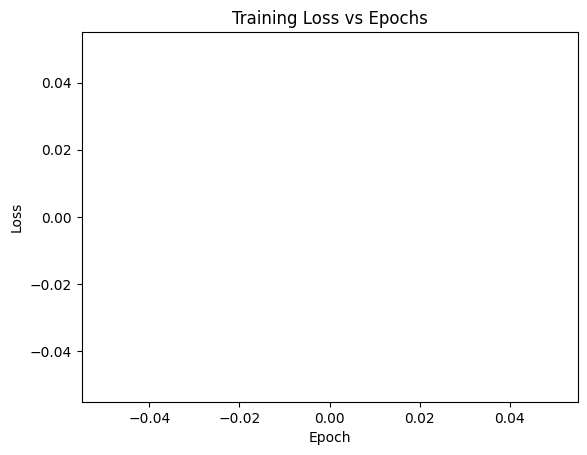

In [20]:
# Evaluating algorithm accuracy
plt.plot(range(len(errors)), errors)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()

# Building the CNN

In [ ]:
# setting all images to same img size
from PIL import Image, ImageOps

def convert_image_to_grayscale_with_padding(image_path, target_width=None, target_height=None):
    """
    Converts a single .jpg image to grayscale and optionally pads it to the target dimensions.

    Args:
        image_path (str): Path to the input .jpg image.
        target_width (int, optional): Target width for padding. If None, keeps the original width.
        target_height (int, optional): Target height for padding. If None, keeps the original height.

    Returns:
        np.ndarray: Grayscale image as a numpy array, with optional padding applied.
    """
    # Open the image
    with Image.open(image_path) as img:
        # Convert to grayscale
        grayscale_img = img.convert('L')

        # If target dimensions are provided, pad the image
        if target_width and target_height:
            padded_img = ImageOps.pad(grayscale_img, (target_width, target_height), color=0)
        else:
            padded_img = grayscale_img

        # Convert the image to a numpy array
        grayscale_array = np.array(padded_img)

    return grayscale_array

test = convert_image_to_grayscale_with_padding('/content/Nike.png', 499, 540)

# picture of my cat
def plot_pet(x, im_shape=(540, 499)):
    plt.imshow(x.reshape(im_shape), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.gcf().set_size_inches(4, 4)

plot_pet(test)

In [ ]:
# define the input with the image rows, cols, and grayscale column
inpx = Input(shape=(img_rows, img_cols, 1))

# define convolutional layer 1
con_layer = Conv2D(1, padding = 'same', kernel_size=(4, 4), strides=1, activation=None)(inpx)
con_layer = MaxPooling2D((2,2))(con_layer)
# define convolutional layer 2
con_layer2 = Conv2D(1, kernel_size=(3, 3), strides=1, activation=None)(con_layer)

# flattening the image
flat_G = Flatten()(con_layer2)

# establishing hidden layers
# hidden layer 1
hid_layer = Dense(64, activation='relu')(flat_G)
# hidden layer 2
hid_layer2 = Dense(32, activation='relu')(hid_layer)

# defining output function
out_layer = Dense(1, activation='sigmoid')(hid_layer2)

# fitting the model
model = Model([inpx], out_layer)

model.compile(optimizer="adam",
              loss=binary_crossentropy,
              metrics=['accuracy'])